# Group 19 |  How to run our code | Step-by-step tutorial




**Step 1:**  Download the data from the [Reef Support Google Drive](https://drive.google.com/drive/folders/1mx2OJcVKp1mRbTbjezqWucDXpbGrd_OA) *maks_labels* and put those data to the folder "website" so that our files can find correct path. 


In [24]:
!pip install ultralytics pandas numpy scikit-image matplotlib opencv-python typing seaborn

**Step 2:**  Download all important libraries

In [25]:
import argparse, os, sys, glob, cv2, csv, re, random, argparse
from ultralytics import YOLO
import pandas as pd
import numpy as np
from skimage import measure
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
from typing import List, Tuple, Dict
import seaborn

**STEP 2.5** : We need to transform stitched masks to polygons because that how YOLOv8 our model uses the data.

In [26]:
# --- CONFIG ---
ROOT = Path(r"C:\\Users\\20233416\\Documents\\DC1\\Cap_coral_reefs\\New_version_of_the_project\\website\\benthic_datasets\\mask_labels\\reef_support")

RGB_CLASS_MAP = {
    (255, 0, 0): 0,   # red -> class 0
    (0, 0, 255): 1,   # blue -> class 1
    # add more colors if needed
}

MIN_AREA_PX = 50           # minimum area to keep polygon
APPROX_EPS_FRAC = 0.01     # polygon simplification (0 = no simplify)

# --- FUNCTIONS ---

def load_mask_as_class_ids(mask_path: Path) -> np.ndarray:
    img = Image.open(mask_path)
    if img.mode == "P":
        arr = np.array(img)
        return arr.astype(np.int32)
    if img.mode in ("L", "I;16"):
        arr = np.array(img)
        return arr.astype(np.int32)
    img = img.convert("RGB")
    rgb = np.array(img)
    h, w, _ = rgb.shape
    class_ids = np.full((h, w), fill_value=-1, dtype=np.int32)
    for color, cls in RGB_CLASS_MAP.items():
        mask = (rgb[:, :, 0] == color[0]) & (rgb[:, :, 1] == color[1]) & (rgb[:, :, 2] == color[2])
        class_ids[mask] = cls
    return class_ids

def find_polygons_for_class(bin_mask: np.ndarray, approx_eps_frac: float, min_area_px: int):
    m = (bin_mask.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    polys = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area_px:
            continue
        if approx_eps_frac > 0:
            eps = approx_eps_frac * cv2.arcLength(cnt, True)
            cnt = cv2.approxPolyDP(cnt, eps, True)
        if len(cnt) >= 3:
            polys.append(cnt.reshape(-1, 2))
    return polys

def normalize_polygon(poly_xy: np.ndarray, w: int, h: int):
    xs = poly_xy[:, 0] / float(w)
    ys = poly_xy[:, 1] / float(h)
    out = []
    for x, y in zip(xs, ys):
        out.extend([min(max(float(x), 0.0), 1.0), min(max(float(y), 0.0), 1.0)])
    return out

def write_label(lines, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", encoding="utf-8") as f:
        for line in lines:
            f.write(line.rstrip() + "\n")

def process_pair(image_path: Path, mask_path: Path, label_dir: Path):
    with Image.open(image_path) as im:
        w, h = im.size
    class_ids = load_mask_as_class_ids(mask_path)
    lines = []
    present = np.unique(class_ids)
    for cls in present:
        if cls < 0:
            continue
        bin_mask = (class_ids == cls)
        if not np.any(bin_mask):
            continue
        polys = find_polygons_for_class(bin_mask, APPROX_EPS_FRAC, MIN_AREA_PX)
        for poly in polys:
            coords = normalize_polygon(poly, w, h)
            if len(coords) >= 6:
                line = str(int(cls)) + " " + " ".join(f"{v:.6f}" for v in coords)
                lines.append(line)
    out_path = label_dir / (image_path.stem + ".txt")
    write_label(lines, out_path)

def find_pairs_under(root: Path):
    for sub in root.rglob("*"):
        if not sub.is_dir():
            continue
        if sub.name.lower() == "images":
            images_dir = sub
            masks_dir = images_dir.parent / "masks_stitched"
            if not masks_dir.exists():
                continue
            label_dir = images_dir.parent / "label"
            mask_index = {}
            for m in masks_dir.glob("*.png"):
                stem = m.stem
                for suf in ["_mask", "-mask", "__mask"]:
                    if stem.endswith(suf):
                        stem = stem[: -len(suf)]
                mask_index[stem.lower()] = m
            for img in images_dir.glob("*.*"):
                if img.suffix.lower() not in (".jpg", ".jpeg", ".png", ".tif", ".tiff"):
                    continue
                key = img.stem.lower()
                if key in mask_index:
                    yield img, mask_index[key], label_dir

# --- RUN ---
pairs = list(find_pairs_under(ROOT))
print(f"Found {len(pairs)} image/mask pairs.")

for img, msk, lbl in pairs:
    try:
        process_pair(img, msk, lbl)
        print(f"✓ {img.name} -> {lbl/(img.stem + '.txt')}")
    except Exception as e:
        print(f"✗ Failed {img} with {msk}: {e}")

print("Done.")


Found 3311 image/mask pairs.
✗ Failed C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support\SEAFLOWER_BOLIVAR\images\20220912_AnB_CB10 (103).JPG with C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support\SEAFLOWER_BOLIVAR\masks_stitched\20220912_AnB_CB10 (103)_mask.png: name 'Image' is not defined
✗ Failed C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support\SEAFLOWER_BOLIVAR\images\20220912_AnB_CB10 (104).JPG with C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support\SEAFLOWER_BOLIVAR\masks_stitched\20220912_AnB_CB10 (104)_mask.png: name 'Image' is not defined
✗ Failed C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support\SEAFLOWER_BOL

**Step 3:** We need to create CSV file which will be our "dictionary"  with following columns:

|type_x | name | name_ext | path| label_name| label_name_ext | label_path | polygon_count | type_y |soft_area | hard_area | total_area|

**type_X** - Whether file is mask or image\
**name** - name of the file e.g Coral1\
**name_ext** - name of the file with file extension e.g Coral1.png\
**path** - path to the file\
**label_name** - if an object is image then there is a label_name which corresponds to the name of the file e.g Coral1_mask\
**label_name_ect** - if an object is image then there is label_name which corresponding name and file extension e.g Coral1_mask.txt\
**label_path** - path to the label\
**polygon_count** - the number of corals in one picture e.g 53\
**type_y** - [soft-only, hard-only, mixed] corals\
**soft_area** - % of what soft corals are in the picture\
**hard_area** - % of what hard corals are in the picture\
**total_area** - % of what corals are taking the picture combined (soft_area + hard_area)

Code to create "output.csv" (**Remember to adjust ROOT**)



In [27]:
from pathlib import Path
import pandas as pd

ROOT = r"C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support"

IMG_EXTS = {".jpg", ".jpeg", ".png"}
MASK_EXTS = {".png", ".tif", ".tiff"}

def creating_dataframe():
    rows = []
    root = Path(ROOT)
    if not root.exists():
        print(f"[need] ROOT not found: {ROOT}")
        return

    subs = sorted(p for p in root.iterdir() if p.is_dir())
    if not subs:
        print(f"[warn] No subfolders inside {ROOT}")
    for sub in subs:
        images_path = sub / "images"
        masks_stitched_path = sub / "masks_stitched"
        folder_name = sub.name

        # masks
        if masks_stitched_path.exists():
            for mask in masks_stitched_path.iterdir():
                if mask.is_file() and mask.suffix.lower() in MASK_EXTS:
                    rows.append({
                        "type": "mask",
                        "name": mask.stem.strip(),
                        "name_ext": mask.name,
                        "path": str(mask),
                        "folder": folder_name
                    })

        # images
        if images_path.exists():
            for image in images_path.iterdir():
                if image.is_file() and image.suffix.lower() in IMG_EXTS:
                    rows.append({
                        "type": "image",
                        "name": image.stem.strip(),
                        "name_ext": image.name,
                        "path": str(image),
                        "folder": folder_name
                    })

    df = pd.DataFrame(rows, columns=["type", "name", "name_ext", "path", "folder"])
    df.to_csv("output.csv", index=False)
    print(f"[ok] Wrote output.csv with {len(df)} rows")

def adding_labels_fixed():
    out = Path("output.csv")
    if not out.exists():
        print("[need] output.csv not found — run creating_dataframe() first.")
        return

    df = pd.read_csv(out)

    # ensure label columns exist
    for c in ["label_name", "label_name_ext", "label_path"]:
        if c not in df.columns:
            df[c] = pd.NA

    root = Path(ROOT)
    if not root.exists():
        print(f"[need] ROOT not found: {ROOT}")
        return

    label_dirnames = ("labels", "label")  # <<< support singular & plural
    updates = 0
    label_files_seen = 0
    subs = sorted(p for p in root.iterdir() if p.is_dir())
    print(f"[info] Found {len(subs)} subfolders under ROOT.")

    for sub in subs:
        folder_name = sub.name

        # find first existing label dir among candidates
        lp = None
        for d in label_dirnames:
            cand = sub / d
            if cand.exists() and cand.is_dir():
                lp = cand
                break

        if lp is None:
            print(f"  [skip] {folder_name}: no 'labels' or 'label' dir")
            continue

        print(f"  [check] {folder_name}: using '{lp.name}' dir -> {lp}")

        for txt in lp.iterdir():
            if not txt.is_file():
                print(f"    [skip] {txt.name} (not a file)")
                continue

            if txt.suffix.lower() != ".txt":
                print(f"    [warn] {txt.name}: skipped (ext={txt.suffix})")
                continue

            label_files_seen += 1
            stem = txt.stem.strip()
            mask = (df["type"] == "image") & (df["folder"] == folder_name) & (df["name"] == stem)
            hit_count = int(mask.sum())

            if hit_count == 0:
                print(f"    [no match] '{stem}' in folder='{folder_name}'")
            else:
                df.loc[mask, "label_name"] = stem
                df.loc[mask, "label_name_ext"] = txt.name
                df.loc[mask, "label_path"] = str(txt)
                print(f"    [match] '{stem}' -> {hit_count} image row(s)")
                updates += hit_count

    df.to_csv(out, index=False)
    print(f"[ok] Scanned {label_files_seen} .txt files. Updated labels for {updates} image rows in output.csv")

creating_dataframe()


adding_labels_fixed()

[ok] Wrote output.csv with 6622 rows
[info] Found 8 subfolders under ROOT.
  [check] SEAFLOWER_BOLIVAR: using 'labels' dir -> C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support\SEAFLOWER_BOLIVAR\labels
    [match] '20220912_AnB_CB10 (103)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (104)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (110)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (111)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (113)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (118)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (12)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (121)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (122)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (124)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (125)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (126)' -> 1 image row(s)
    [match] '20220912_AnB_CB10 (127)' -> 1 image row(

 In order to finish this csv we might need to use a help of additional one "poly.csv" which focuses on each coral and additionally we create some EDA

In [28]:

# >>>>> EDIT THESE TWO ONLY <<<<<
ROOT = Path(r"C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\website\benthic_datasets\mask_labels\reef_support")
OUTPUT_PATH = Path(r"C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\output.csv")

# Optional derived paths
POLYS_PATH = OUTPUT_PATH.with_name("polys.csv")
FIG_DIR = OUTPUT_PATH.with_name("figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _ok(p: Path): print(f"[ok] {p}")
def _skip(msg: str): print(f"[skip] {msg}")
def _need(p: Path): print(f"[need] {p} is required and not found.")


In [29]:
# ==== STAGE 2: enrich output.csv with labels (label_name/_ext/_path) ====
def adding_labels(root: Path, out_csv: Path):
    if not out_csv.exists():
        _need(out_csv); return
    df = pd.read_csv(out_csv)

    # ensure columns exist
    for c in ["label_name", "label_name_ext", "label_path"]:
        if c not in df.columns: df[c] = None

    if not root.exists():
        _need(root); return

    updates = 0
    for sub in sorted([p for p in root.iterdir() if p.is_dir()]):
        labels_path = sub / "labels"
        if not labels_path.exists():
            continue
        for txt in labels_path.iterdir():
            if txt.is_file():
                text_name, text_name_ext, text_path = txt.stem, txt.name, str(txt)
                mask = df["name"].astype(str).eq(text_name)
                if mask.any():
                    df.loc[mask, "label_name"] = text_name
                    df.loc[mask, "label_name_ext"] = text_name_ext
                    df.loc[mask, "label_path"] = text_path
                    updates += int(mask.sum())

    df.to_csv(out_csv, index=False)
    _ok(f"Updated {out_csv} label columns for {updates} rows")

# Run stage 2
adding_labels(ROOT, OUTPUT_PATH)


[ok] Updated C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\output.csv label columns for 3311 rows


In [30]:
# ==== STAGE 3: parse labels -> polys.csv ====
def parse_single_label_file(label_path: str, image_path: str, image_name: str) -> pd.DataFrame:
    lines = Path(label_path).read_text(encoding="utf-8").strip().splitlines()
    rows = []
    for i, line in enumerate(lines):
        vals = [float(v) for v in line.strip().split()]
        cls = int(vals[0])
        coords = np.array(vals[1:], dtype=float).reshape(-1, 2)
        rows.append({
            "polygon_id": f"{image_name}_{i}",
            "file": image_name,
            "file_path": str(image_path),
            "label_path": str(label_path),
            "class_id": cls,
            "coords": coords.tolist(),   # make JSON-friendly
            "n_vertices": len(coords),
        })
    return pd.DataFrame(rows)

def build_polys_csv(out_csv: Path, polys_csv: Path):
    if not out_csv.exists():
        _need(out_csv); return
    meta = pd.read_csv(out_csv)
    all_rows = []
    for _, r in meta.iterrows():
        img_path = r.get("path")
        lbl_path = r.get("label_path")
        if pd.isna(lbl_path) or not lbl_path:
            continue
        lp = Path(str(lbl_path))
        if not lp.exists():
            continue
        img_name = Path(str(img_path)).stem if not pd.isna(img_path) else lp.stem
        df_one = parse_single_label_file(str(lp), str(img_path), img_name)
        if not df_one.empty:
            all_rows.append(df_one)
    if not all_rows:
        _skip("No polygons parsed; polys.csv not written."); return
    polys = pd.concat(all_rows, ignore_index=True)
    polys.to_csv(polys_csv, index=False)
    _ok(f"Wrote {polys_csv} with {len(polys)} polygons")

# Run stage 3
build_polys_csv(OUTPUT_PATH, POLYS_PATH)


[ok] Wrote C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\polys.csv with 80298 polygons


In [31]:
# ==== STAGE 4A: add polygon_count per file ====
def add_polygon_count(polys_csv: Path, out_csv: Path):
    if not polys_csv.exists(): _need(polys_csv); return
    if not out_csv.exists(): _need(out_csv); return

    df_polys = pd.read_csv(polys_csv)
    df_out = pd.read_csv(out_csv)

    counts = df_polys.groupby("file").size()
    df_out = df_out.merge(counts.rename("polygon_count"),
                          left_on="name", right_index=True, how="left")
    df_out["polygon_count"] = df_out["polygon_count"].fillna(0).astype(int)
    df_out.to_csv(out_csv, index=False)
    _ok("Added polygon_count to output.csv")

# ==== STAGE 4B: classify files (hard-only / soft-only / mixed) ====
def add_file_classification(polys_csv: Path, out_csv: Path):
    if not polys_csv.exists(): _need(polys_csv); return
    if not out_csv.exists(): _need(out_csv); return

    df_polys = pd.read_csv(polys_csv)
    df_out = pd.read_csv(out_csv)

    if df_polys.empty:
        _skip("polys.csv empty; classification skipped"); return

    classes_per_file = df_polys.groupby("file")["class_id"].apply(set)
    classification = classes_per_file.apply(
        lambda s: "hard-only" if s == {0}
        else "soft-only" if s == {1}
        else "mixed"
    )
    # Merge; if 'type' already exists, pandas will make type_x/type_y
    df_out = df_out.merge(classification.rename("type"),
                          left_on="name", right_index=True, how="left")
    df_out.to_csv(out_csv, index=False)
    _ok("Added classification (type_y) to output.csv (if type existed already)")

# ==== STAGE 4C: compute soft/hard/total areas from label files ====
def polygon_area(xs, ys):
    n = len(xs)
    if n < 3 or n != len(ys): return 0.0
    if xs[0] == xs[-1] and ys[0] == ys[-1]:
        xs, ys = xs[:-1], ys[:-1]; n -= 1
        if n < 3: return 0.0
    return 0.5 * abs(sum(xs[i]*ys[(i+1)%n] - xs[(i+1)%n]*ys[i] for i in range(n)))

def read_label_file(path):
    hard_area = 0.0; soft_area = 0.0
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if not parts or len(parts) < 7: continue
                try:
                    cls = int(parts[0]); coords = list(map(float, parts[1:]))
                except ValueError:
                    continue
                if len(coords) % 2 != 0: continue
                xs = coords[0::2]; ys = coords[1::2]
                a = polygon_area(xs, ys)
                if a <= 0: continue
                if cls == 0: hard_area += a
                elif cls == 1: soft_area += a
    except FileNotFoundError:
        pass
    return hard_area, soft_area

def add_areas(out_csv: Path):
    if not out_csv.exists(): _need(out_csv); return
    df = pd.read_csv(out_csv)

    # Identify original type column (might be 'type' or 'type_x' after merge)
    type_col = "type_x" if "type_x" in df.columns else ("type" if "type" in df.columns else None)
    if type_col is None:
        _skip("No original 'type' column to filter images; computing areas for all rows.")
        mask_idx = df.index
    else:
        mask_idx = df.index[df[type_col] == "image"]

    for col in ["soft_area", "hard_area", "total_area"]:
        if col not in df.columns: df[col] = np.nan

    for idx in mask_idx:
        p = df.loc[idx, "label_path"] if "label_path" in df.columns else None
        if pd.isna(p) or not p: continue
        h, s = read_label_file(p)
        df.loc[idx, "soft_area"] = s
        df.loc[idx, "hard_area"] = h
        df.loc[idx, "total_area"] = s + h

    df.to_csv(out_csv, index=False)
    _ok("Added soft_area / hard_area / total_area to output.csv")

# Run stage 4
add_polygon_count(POLYS_PATH, OUTPUT_PATH)
add_file_classification(POLYS_PATH, OUTPUT_PATH)
add_areas(OUTPUT_PATH)


[ok] Added polygon_count to output.csv
[ok] Added classification (type_y) to output.csv (if type existed already)
[ok] Added soft_area / hard_area / total_area to output.csv


In [32]:
# ==== STAGE 5: plotting helpers ====
def load_and_prepare(csv_path: Path):
    if not csv_path.exists():
        _need(csv_path); return pd.DataFrame()
    df = pd.read_csv(csv_path)
    for col in ["polygon_count", "soft_area", "hard_area", "total_area"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if {"total_area", "soft_area", "hard_area"}.issubset(df.columns):
        need = df["total_area"].isna() & df["soft_area"].notna() & df["hard_area"].notna()
        df.loc[need, "total_area"] = df.loc[need, "soft_area"] + df.loc[need, "hard_area"]
    return df

def save_show(name):
    plt.tight_layout()
    p = FIG_DIR / name
    plt.savefig(p, bbox_inches="tight", dpi=150)
    plt.close()
    print(f"[fig] {p}")

def plot_hist_ecdf_box(df):
    numeric_cols = [c for c in ["soft_area","hard_area","total_area"] if c in df.columns and df[c].notna().any()]
    for col in numeric_cols:
        # hist
        plt.figure(); plt.hist(df[col].dropna().values, bins=40)
        plt.title(f"Distribution of {col}"); plt.xlabel(col); plt.ylabel("Count")
        save_show(f"hist_{col}.png")
        # ecdf
        x = np.sort(df[col].dropna().values); y = np.arange(1, len(x)+1)/len(x)
        plt.figure(); plt.step(x, y, where="post")
        plt.title(f"ECDF of {col}"); plt.xlabel(col); plt.ylabel("F(x)")
        save_show(f"ecdf_{col}.png")
    # box by type_y if present
    if "type_y" in df.columns and any(df["type_y"].notna()):
        for col in numeric_cols:
            groups = [g[col].dropna().values for _, g in df.groupby("type_y")]
            labels = [str(k) for k, _ in df.groupby("type_y")]
            if any(len(g) for g in groups):
                plt.figure(); plt.boxplot(groups, labels=labels)
                plt.title(f"{col} by type_y"); plt.ylabel(col); plt.xlabel("type_y")
                save_show(f"box_{col}_by_type.png")

def plot_soft_vs_hard(df):
    if {"soft_area","hard_area"}.issubset(df.columns):
        d = df.dropna(subset=["soft_area","hard_area"])
        if len(d) == 0: return
        lim = max(d["soft_area"].max(), d["hard_area"].max())
        plt.figure(); plt.scatter(d["soft_area"], d["hard_area"], alpha=0.6)
        plt.plot([0, lim], [0, lim])
        plt.title("Soft vs Hard Area (scatter)"); plt.xlabel("soft_area"); plt.ylabel("hard_area")
        save_show("scatter_soft_vs_hard.png")

def plot_polygon_bins(df):
    if "polygon_count" not in df.columns: return
    bins = list(range(1, 131, 10))
    labels = [f"{b}-{b+9}" for b in bins[:-1]]
    tmp = df.copy()
    tmp["polygon_bin"] = pd.cut(tmp["polygon_count"], bins=bins, labels=labels, include_lowest=True)
    tmp = tmp.dropna(subset=["polygon_bin"])
    if "type_y" in tmp.columns and not tmp.empty:
        tab = tmp.groupby(["polygon_bin","type_y"]).size().unstack(fill_value=0)

        # grouped bars
        plt.figure()
        x = np.arange(len(tab.index)); width = 0.8 / max(1, len(tab.columns))
        for i, col in enumerate(tab.columns):
            plt.bar(x + i*width, tab[col].values, width, label=str(col))
        plt.xticks(x + width*(len(tab.columns)-1)/2, tab.index, rotation=45)
        plt.title("Polygon count by bin and type_y")
        plt.xlabel("polygon_count bin"); plt.ylabel("Count")
        plt.legend(title="type_y"); save_show("bars_polygon_bins_grouped.png")

        # 100% stacked
        perc = tab.div(tab.sum(axis=1), axis=0).fillna(0)
        plt.figure()
        bottom = np.zeros(len(perc))
        for col in perc.columns:
            plt.bar(perc.index.astype(str), perc[col].values, bottom=bottom, label=str(col))
            bottom += perc[col].values
        plt.xticks(rotation=45)
        plt.title("Polygon count composition by bin (100% stacked)")
        plt.xlabel("polygon_count bin"); plt.ylabel("Share")
        plt.legend(title="type_y"); save_show("bars_polygon_bins_100pct.png")

def plot_corr(df):
    cols = [c for c in ["polygon_count","soft_area","hard_area","total_area"] if c in df.columns]
    if not cols: return
    corr = df[cols].corr(numeric_only=True)
    plt.figure(); plt.imshow(corr, interpolation="nearest")
    plt.xticks(range(len(cols)), cols, rotation=45, ha="right"); plt.yticks(range(len(cols)), cols)
    plt.title("Correlation matrix"); cb = plt.colorbar(); cb.set_label("corr")
    save_show("correlation_matrix.png")

# Run stage 5
dfp = load_and_prepare(OUTPUT_PATH)
if not dfp.empty:
    plot_hist_ecdf_box(dfp)
    plot_soft_vs_hard(dfp)
    plot_polygon_bins(dfp)
    plot_corr(dfp)


[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\hist_soft_area.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\ecdf_soft_area.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\hist_hard_area.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\ecdf_hard_area.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\hist_total_area.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\ecdf_total_area.png


C:\tmp\ipykernel_25084\3956900605.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.figure(); plt.boxplot(groups, labels=labels)
C:\tmp\ipykernel_25084\3956900605.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.figure(); plt.boxplot(groups, labels=labels)


[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\box_soft_area_by_type.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\box_hard_area_by_type.png


C:\tmp\ipykernel_25084\3956900605.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.figure(); plt.boxplot(groups, labels=labels)


[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\box_total_area_by_type.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\scatter_soft_vs_hard.png


C:\tmp\ipykernel_25084\3956900605.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby(["polygon_bin","type_y"]).size().unstack(fill_value=0)


[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\bars_polygon_bins_grouped.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\bars_polygon_bins_100pct.png
[fig] C:\Users\20233416\Documents\DC1\Cap_coral_reefs\New_version_of_the_project\figs\correlation_matrix.png


We are done with the first part! Now let's focus on model 


To do so we need to have few important things:
1. Model [Download](https://huggingface.co/reefsupport/coral-ai/resolve/main/models/yolov8_sm_latest.pt)
2. All traning,val,test data [Download](https://tuenl-my.sharepoint.com/:f:/g/personal/j_i_kuczynski_student_tue_nl/EtoFKoLvgR1GpKCXpZfeZfoBv485qEcsh4mnGzUiKx-TTQ?e=hR5zaI)
This files you need to put to the folder "splits" 
3. Create data.yaml which you can also Download [here](https://tuenl-my.sharepoint.com/:f:/g/personal/j_i_kuczynski_student_tue_nl/EtoFKoLvgR1GpKCXpZfeZfoBv485qEcsh4mnGzUiKx-TTQ?e=hR5zaI)
And remember to adjust data.yaml to have correct path


**Step 4:** Create balanced train sets.\
Run this code to generate train sets that are balanced with linear and sqrt Repeat Factor Sampling (they will be in the splits folder):

In [33]:
def read_lines(p):
    with open(p, "r", encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]


def image_to_label_path(img_path):
    s = img_path.replace("\\", "/")
    s = re.sub(r"[\\/]+images[\\/]+", "/labels/", s)
    s = re.sub(r"\.(jpg|jpeg|png|bmp)$", ".txt", s, flags=re.I)
    return s


def count_classes_in_label(lbl_path):
    cnt = Counter()
    if not os.path.exists(lbl_path):
        return cnt
    with open(lbl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                cls = int(float(line.split()[0]))
                cnt[cls] += 1
            except Exception:
                pass
    return cnt


def build_index(train_list):
    per_img = []
    inst_tot = Counter()
    for img in train_list:
        lbl = image_to_label_path(img)
        c = count_classes_in_label(lbl)
        per_img.append((img, c))
        inst_tot.update(c)
    return per_img, inst_tot


def rfs_repeat_factors(inst_tot, alpha=0.5):
    """
    r_c = max(1, (f_min / f_c)^alpha)
    alpha=0.5 -> sqrt scaling (gentle)
    alpha=1.0 -> linear scaling (stronger)
    """
    tot_instances = sum(inst_tot.values())
    if tot_instances == 0:
        return {c: 1.0 for c in inst_tot}
    freq = {c: inst_tot[c] / tot_instances for c in inst_tot}
    f_min = min(freq.values()) if freq else 1.0
    r_class = {c: max(1.0, (f_min / max(freq[c], 1e-12)) ** alpha) for c in inst_tot}
    return r_class


def make_list(per_img, r_class, max_repeat=6, seed=0):
    out = []
    rng = random.Random(seed)
    for img, c in per_img:
        r = 1.0
        for cls, n in c.items():
            if n > 0:
                r = max(r, r_class.get(cls, 1.0) * (n ** 0.5))
        r = min(max_repeat, r)
        base = int(r)
        frac = r - base
        repeats = base + (1 if rng.random() < frac else 0)
        out.extend([img] * max(1, repeats))
    rng.shuffle(out)
    return out


def write_list(path, items):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(items))


def process_one(train_path, tag, args):
    base = read_lines(train_path)
    per_img, inst_tot = build_index(base)
    print(f"\n=== {tag} ===")
    print(f"Train list: {train_path}  (images: {len(base)})")
    print(f"Total instances: {dict(inst_tot)}")

    r_class_sqrt = rfs_repeat_factors(inst_tot, alpha=args.alpha_sqrt)
    r_class_lin = rfs_repeat_factors(inst_tot, alpha=args.alpha_linear)

    lst_sqrt = make_list(per_img, r_class_sqrt, max_repeat=args.sqrt_max_repeat, seed=args.seed)
    lst_linear = make_list(per_img, r_class_lin, max_repeat=args.linear_max_repeat, seed=args.seed)

    p_sqrt = os.path.join("splits", f"train_rfs_sqrt_{tag}.txt")
    p_linear = os.path.join("splits", f"train_rfs_linear_{tag}.txt")
    write_list(p_sqrt, lst_sqrt)
    write_list(p_linear, lst_linear)

    print(f"Wrote:\n  {p_sqrt}   (n={len(lst_sqrt)})\n  {p_linear} (n={len(lst_linear)})")
    return p_sqrt, p_linear


def main():
    ap = argparse.ArgumentParser(description="Build RFS train lists for one or more train splits.")
    ap.add_argument("--trains", nargs="+", required=True, help="Paths to train list(s), e.g. splits/train_*.txt")
    ap.add_argument("--tags", nargs="*", help="Tags to append (auto from filename if omitted)")
    ap.add_argument("--alpha_sqrt", type=float, default=0.5, help="Alpha for sqrt/gentle scaling")
    ap.add_argument("--alpha_linear", type=float, default=1.0, help="Alpha for linear/strong scaling")
    ap.add_argument("--sqrt_max_repeat", type=int, default=6, help="Max repeats for sqrt version")
    ap.add_argument("--linear_max_repeat", type=int, default=8, help="Max repeats for linear version")
    ap.add_argument("--seed", type=int, default=0)
    args = ap.parse_args()

    tags = args.tags or [Path(p).stem.replace("train_", "") for p in args.trains]
    if len(tags) != len(args.trains):
        raise SystemExit("[ERROR] Number of --tags must match number of --trains")

    for train_path, tag in zip(args.trains, tags):
        if not os.path.exists(train_path):
            print(f"[WARN] File not found: {train_path}")
            continue
        process_one(train_path, tag, args)



Run this code to generate train sets that are balanced with Random Oversampling (they will be in the splits folder):

In [34]:
def read_lines(p):
    with open(p, "r", encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]


def image_to_label_path(img_path):
    s = img_path.replace("\\", "/")
    s = re.sub(r"[\\/]+images[\\/]+", "/labels/", s)
    s = re.sub(r"\.(jpg|jpeg|png|bmp)$", ".txt", s, flags=re.I)
    return s


def count_classes_in_label(lbl_path):
    c = Counter()
    if not os.path.exists(lbl_path):
        return c
    with open(lbl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split()
            try:
                cls = int(float(parts[0]));
                c[cls] += 1
            except Exception:
                pass
    return c


def build_index(train_list):
    per_img, totals = [], Counter()
    for img in train_list:
        cnt = count_classes_in_label(image_to_label_path(img))
        per_img.append((img, cnt))
        totals.update(cnt)
    return per_img, totals


def compute_max_reachable_ratio(per_img, soft_id, hard_id, max_repeat_per_image):
    base = Counter()
    for _, cnt in per_img: base.update(cnt)
    S0, H0 = base[soft_id], (base[hard_id] if base[hard_id] > 0 else 1)
    S_add = H_add = 0
    for _, cnt in per_img:
        if cnt.get(soft_id, 0) > 0:
            S_add += cnt.get(soft_id, 0) * max_repeat_per_image
            H_add += cnt.get(hard_id, 0) * max_repeat_per_image
    S_max, H_max = S0 + S_add, H0 + H_add
    return S0, H0, S_max, H_max, (S_max / max(H_max, 1))


def random_oversample(per_img, soft_id, hard_id, target_ratio=1.0,
                      max_repeat_per_image=8, max_iterations=2_000_000,
                      progress_every=100_000):
    rng = random.Random(0)
    out = [img for img, _ in per_img]
    totals = Counter()
    soft_pool = []
    for img, cnt in per_img:
        totals.update(cnt)
        if cnt.get(soft_id, 0) > 0:
            soft_pool.append((img, cnt))
    if totals[soft_id] == 0:
        raise RuntimeError("No soft (minority) instances found—check class ids and labels.")
    if totals[hard_id] == 0:
        totals[hard_id] = 1

    def ratio(t):
        return t[soft_id] / max(t[hard_id], 1)

    # Reachability clamp
    _, _, _, _, max_reach = compute_max_reachable_ratio(per_img, soft_id, hard_id, max_repeat_per_image)
    if target_ratio > max_reach + 1e-9:
        print(f"[WARN] Target ratio {target_ratio:.3f} unreachable with max_repeat={max_repeat_per_image}. "
              f"Clamping to ≈ {max_reach:.3f}.")
        target_ratio = max_reach

    if ratio(totals) >= target_ratio:
        rng.shuffle(out);
        return out, dict(totals)

    repeats = Counter()
    iters = 0
    while ratio(totals) < target_ratio and iters < max_iterations:
        iters += 1
        img, cnt = rng.choice(soft_pool)
        if repeats[img] >= max_repeat_per_image:
            continue
        out.append(img);
        repeats[img] += 1;
        totals.update(cnt)
        if progress_every and (iters % progress_every) == 0:
            print(f"[oversample] iter={iters:,}  ratio={ratio(totals):.4f}  target={target_ratio:.4f}  "
                  f"capped_imgs={sum(1 for v in repeats.values() if v >= max_repeat_per_image)}")
    if iters >= max_iterations and ratio(totals) < target_ratio - 1e-6:
        print(f"[WARN] Stopped at {iters:,} iters; ratio={ratio(totals):.4f} < target={target_ratio:.4f}. "
              f"Try higher --max_repeat or lower --target.")
    rng.shuffle(out);
    return out, dict(totals)


def write_list(path, items):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(items))


def main():
    import argparse
    ap = argparse.ArgumentParser(description="Random oversampling for class balance (soft coral).")
    ap.add_argument("--train", required=True, help="Path to baseline train list")
    ap.add_argument("--soft_id", type=int, required=True, help="Soft coral class id (usually 1)")
    ap.add_argument("--hard_id", type=int, default=0, help="Hard coral class id (usually 0)")
    ap.add_argument("--tag", type=str, default="", help="Suffix for output filename (e.g., realistic)")
    ap.add_argument("--target", type=float, default=1.0, help="Target soft:hard ratio")
    ap.add_argument("--max_repeat", type=int, default=8, help="Max repeats per image")
    ap.add_argument("--max_iter", type=int, default=2_000_000, help="Failsafe iteration cap")
    ap.add_argument("--progress_every", type=int, default=50_000, help="Progress print frequency (0 to disable)")
    args = ap.parse_args()

    base = read_lines(args.train)
    per_img, base_tot = build_index(base)
    print("=== Baseline instance totals ===")
    for k in sorted(base_tot): print(f"class {k}: {base_tot[k]}")
    print(f"Images in baseline: {len(per_img)}")
    S0, H0, _, _, max_reach = compute_max_reachable_ratio(per_img, args.soft_id, args.hard_id, args.max_repeat)
    curr = S0 / max(H0, 1)
    print(f"Current soft:hard ≈ {curr:.3f} | Max reachable with max_repeat={args.max_repeat}: ≈ {max_reach:.3f}")

    out_list, out_tot = random_oversample(
        per_img, args.soft_id, args.hard_id,
        target_ratio=args.target,
        max_repeat_per_image=args.max_repeat,
        max_iterations=args.max_iter,
        progress_every=args.progress_every
    )
    tag = f"__{args.tag}" if args.tag else ""
    out_path = os.path.join("splits", f"train_oversampling{tag}.txt")
    write_list(out_path, out_list)
    final_ratio = out_tot[args.soft_id] / max(out_tot[args.hard_id], 1)
    print(f"\nWrote:\n  {out_path} (lines: {len(out_list)})")
    print(f"Approx totals after oversampling: {out_tot}")
    print(f"Final soft:hard ≈ {final_ratio:.3f}")
    print(f'Use with: --names "{args.tag or "oversampling"}:{out_path}"')



Now if we have everything ready, we can proceed with next steps.\
In this code below we are going to train model, we are using different traning data so user has to adjust it in line - 19 -  and change training path in data.yaml. User should train the model on each file beginning with "train" in the "splits" folder.


In [35]:
def parse_args():
    """
    Parse command line arguments for YOLOv8 training.
    """
    ap = argparse.ArgumentParser()
    ap.add_argument("--model", default="yolov8_sm_latest.pt", help="Path to YOLOv8 seg model .pt")
    ap.add_argument("--data", default="data.yaml", help="Path to base data.yaml (fixed val/test)")
    ap.add_argument("--runs", default="runs", help="Directory to store runs")
    ap.add_argument("--epochs", type=int, default=20)
    ap.add_argument("--imgsz", type=int, default=640)
    ap.add_argument("--batch", default="auto", help='int/float or "auto"')
    ap.add_argument("--freeze", type=int, default=10)
    ap.add_argument("--workers", type=int, default=2)
    ap.add_argument("--seeds", type=int, nargs="+", default=[0])
    ap.add_argument("--device", default=None, help="CUDA device index, e.g. 0; leave empty for auto")
    ap.add_argument(
        "--names",
        nargs="+",
        default=["baseline_realistic:splits/train_realistic.txt"],
        help="Pairs name:train_list.txt (space separated)"
    )
    return ap.parse_args()


def _normalize_batch(b):
    """
    Normalize batch parameter: convert 'auto' -> -1, or cast string to int/float.
    """
    if isinstance(b, (int, float)):
        return b
    if isinstance(b, str):
        if b.lower() == "auto":
            return -1
        try:
            return int(b)
        except ValueError:
            return float(b)
    return b


def main():
    """
    Main function to run YOLOv8 training with multiple seeds and dataset splits.
    """
    args = parse_args()

    if not os.path.exists(args.model):
        print(f"[ERROR] Model .pt not found: {args.model}")
        sys.exit(1)
    if not os.path.exists(args.data):
        print(f"[ERROR] data.yaml not found: {args.data}")
        sys.exit(1)
    os.makedirs(args.runs, exist_ok=True)

    pairs = {}
    for item in args.names:
        if ":" not in item:
            print(f"[ERROR] Bad --names item (expected name:path): {item}")
            sys.exit(1)
        name, train_list = item.split(":", 1)
        if not os.path.exists(train_list):
            print(f"[ERROR] Train list not found: {train_list}")
            sys.exit(1)
        pairs[name] = train_list

    with open(args.data, "r", encoding="utf-8") as f:
        base_yaml = f.read()

    batch_val = _normalize_batch(args.batch)

    for seed in args.seeds:
        for name, train_list in pairs.items():
            print(f"\n=== Starting training: {name} (seed {seed}) ===")
            tmp_yaml = os.path.join(os.path.dirname(args.data), f"data_{name}_s{seed}.yaml")
            lines, swapped = [], False
            for line in base_yaml.splitlines():
                if line.strip().lower().startswith("train:"):
                    lines.append(f"train: {train_list}")
                    swapped = True
                else:
                    lines.append(line)
            if not swapped:
                lines.append(f"train: {train_list}")
            with open(tmp_yaml, "w", encoding="utf-8") as f:
                f.write("\n".join(lines))

            run_name = f"{name}_s{seed}"
            try:
                model = YOLO(args.model)
                model.train(
                    data=tmp_yaml,
                    imgsz=args.imgsz,
                    epochs=args.epochs,
                    batch=batch_val,
                    freeze=args.freeze,
                    workers=args.workers,
                    seed=seed,
                    device=args.device,
                    project=args.runs,
                    name=run_name
                )
                print(f"✓ Completed: {run_name}")
            except Exception as e:
                print(f"[ERROR] Training failed for {run_name}: {e}")
                sys.exit(1)



After that user should have folder "runs" in which are saved all training data, which will be user to evaluate different approaches:

In [ ]:
def parse_args():
    """
    Parse command line arguments for evaluating YOLOv8 segmentation runs.
    """
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", default="data.yaml", help="Path to data.yaml")
    ap.add_argument("--runs", default="runs", help="A run dir OR a parent dir containing multiple runs")
    ap.add_argument("--out", default="metrics_summary.csv", help="Output CSV")
    ap.add_argument("--split", default="test", choices=["val", "test"], help="Which split to evaluate on")
    ap.add_argument("--plots", action="store_true", help="Also save PR/F1 plots during val")
    return ap.parse_args()


def list_run_dirs(root: str):
    """
    Return a list of run directories containing weights/best.pt.
    """
    root = os.path.abspath(root)
    if os.path.isdir(os.path.join(root, "weights")) and os.path.exists(os.path.join(root, "weights", "best.pt")):
        return [root]
    kids = [p for p in glob.glob(os.path.join(root, "*")) if os.path.isdir(p)]
    runs = [p for p in kids if os.path.exists(os.path.join(p, "weights", "best.pt"))]
    if not runs:
        raise SystemExit(f"No run folders with weights/best.pt found under: {root}")
    return sorted(runs)


def try_get_seg_metrics(m):
    """
    Extract segmentation evaluation metrics from a YOLOv8 results object.
    """
    out = {}
    seg = getattr(m, "seg", None)
    if seg is not None:
        out["mAP50-95_all"] = float(getattr(seg, "map", float("nan")))
        out["mAP50_all"] = float(getattr(seg, "map50", float("nan")))
        out["per_class"] = list(getattr(seg, "maps", []))
        return out
    rd = getattr(m, "results_dict", None) or {}
    for k in ("metrics/seg_mAP50-95", "metrics/seg_map50-95", "metrics/mAP50-95(M)"):
        if k in rd:
            out["mAP50-95_all"] = float(rd[k])
            break
    for k in ("metrics/seg_mAP50", "metrics/seg_map50", "metrics/mAP50(M)"):
        if k in rd:
            out["mAP50_all"] = float(rd[k])
            break
    out["per_class"] = []
    return out


def main():
    """
    Evaluate YOLOv8 segmentation runs and save per-class + overall metrics to a CSV.
    """
    args = parse_args()
    runs = list_run_dirs(args.runs)

    any_best = os.path.join(runs[0], "weights", "best.pt")
    names = YOLO(any_best).names
    if isinstance(names, dict):
        class_names = [names[i] for i in range(len(names))]
    else:
        class_names = list(names)

    rows = []
    for rd in runs:
        best = os.path.join(rd, "weights", "best.pt")
        run_name = os.path.basename(rd)
        model = YOLO(best)
        metrics = model.val(data=args.data, split=args.split, plots=args.plots)
        seg = try_get_seg_metrics(metrics)

        row = {
            "run": run_name,
            "split": args.split,
            "mAP50-95_all": seg.get("mAP50-95_all", float("nan")),
            "mAP50_all": seg.get("mAP50_all", float("nan")),
        }

        per = seg.get("per_class", [])
        for i, cname in enumerate(class_names):
            row[f"mAP50-95_{cname}"] = float(per[i]) if i < len(per) else float("nan")

        if len(class_names) >= 2:
            a = row.get(f"mAP50-95_{class_names[0]}", float("nan"))
            b = row.get(f"mAP50-95_{class_names[1]}", float("nan"))
            try:
                row["MacroAP50-95"] = (a + b) / 2.0
            except Exception:
                row["MacroAP50-95"] = float("nan")

        rows.append(row)
        print(f"Evaluated {run_name}: mAP50-95_all={row['mAP50-95_all']:.3f}")

    df = pd.DataFrame(rows).sort_values(["run", "split"])
    out_path = os.path.abspath(args.out)
    out_dir = os.path.dirname(out_path) or "."
    os.makedirs(out_dir, exist_ok=True)
    df.to_csv(out_path, index=False)
    print(f"Wrote summary to {out_path}")


if __name__ == "__main__":
    import sys
    in_notebook = "ipykernel" in sys.modules
    main([] if in_notebook else None)


usage: ipykernel_launcher.py [-h] [--data DATA] [--runs RUNS] [--out OUT]
                             [--split {val,test}] [--plots]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\20233416\AppData\Roaming\jupyter\runtime\kernel-v36ccfe030b82bf487ac3b5026ae502d8c446f6c97.json


SystemExit: 2

C:\Users\20233416\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Visualisation Code 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Creating the data from the table
data = {
    "Train set": ["1:1", "1:1", "1:1", "1:1",
                  "realistic", "realistic", "realistic", "realistic",
                  "extreme", "extreme", "extreme", "extreme"],
    "Method": ["RFS - sqrt", "RFS - linear", "Oversampling", "Baseline",
               "RFS - sqrt", "RFS - linear", "Oversampling", "Baseline",
               "RFS - sqrt", "RFS - linear", "Oversampling", "Baseline"],
    "mIoU": [0.558, 0.688, 0.683, 0.588, 0.743, 0.742, 0.746, 0.662, 0.694, 0.668, 0.664, 0.588],
    "IoU(hard)": [0.496, 0.607, 0.604, 0.529, 0.698, 0.697, 0.684, 0.592, 0.677, 0.646, 0.633, 0.571],
    "IoU(soft)": [0.417, 0.607, 0.59, 0.413, 0.648, 0.647, 0.677, 0.551, 0.531, 0.496, 0.501, 0.366],
    "IoU(other)": [0.762, 0.849, 0.857, 0.823, 0.885, 0.883, 0.879, 0.844, 0.873, 0.862, 0.858, 0.827],
    "mDice": [0.705, 0.81, 0.806, 0.726, 0.849, 0.848, 0.852, 0.79, 0.811, 0.791, 0.789, 0.723],
    "Dice(hard)": [0.663, 0.755, 0.753, 0.692, 0.822, 0.821, 0.812, 0.743, 0.808, 0.785, 0.775, 0.727],
    "Dice(soft)": [0.589, 0.756, 0.742, 0.585, 0.786, 0.786, 0.807, 0.711, 0.693, 0.663, 0.668, 0.536],
    "Dice(other)": [0.865, 0.919, 0.923, 0.903, 0.939, 0.938, 0.935, 0.916, 0.932, 0.926, 0.923, 0.905]
}

df = pd.DataFrame(data)




Radar plots visualisation


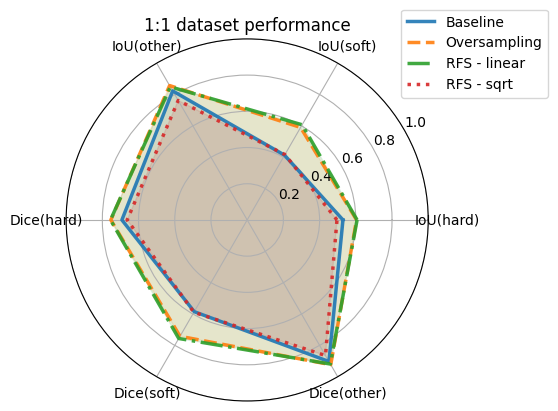

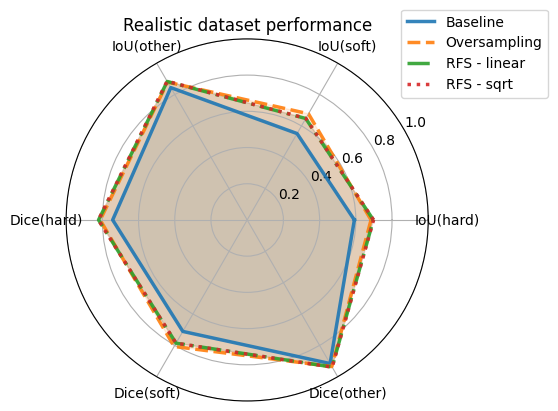

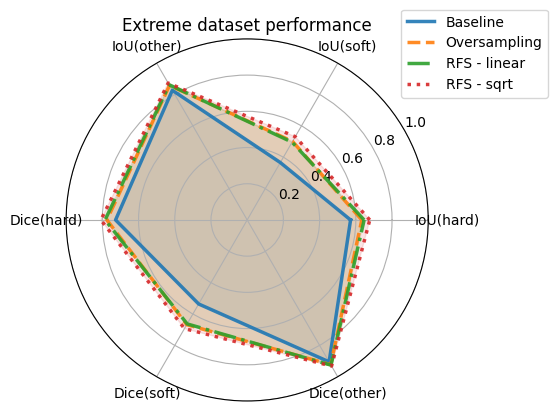

In [ ]:
metrics = ["IoU(hard)", "IoU(soft)", "IoU(other)", "Dice(hard)", "Dice(soft)", "Dice(other)"]

methods = ["Baseline", "Oversampling", "RFS - linear", "RFS - sqrt"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
line_styles = {
    "Baseline": "-",
    "Oversampling": "--",
    "RFS - linear": "-.",
    "RFS - sqrt": ":"
}

for train in df["Train set"].unique():
    subset = df[df["Train set"] == train]
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    for method, color in zip(methods, colors):
        values = subset.loc[subset["Method"] == method, metrics].values.flatten().tolist()
        values += values[:1]

        ax.plot(angles, values, color=color, linewidth=2.5, alpha=0.9,
                linestyle=line_styles[method], label=method)
        ax.fill(angles, values, alpha=0.12, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1)
    ax.set_rlabel_position(30)
    plt.title(f"{train.capitalize()} dataset performance")
    plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    plt.tight_layout()
    plt.show()


Grouped bar chart visualisation

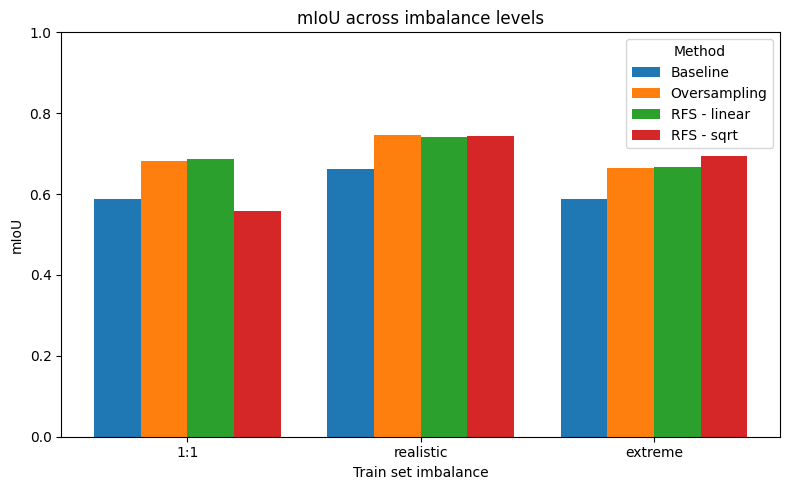

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Metric to plot (we changed it to IoU(soft) and IoU(hard) for poster visualisations, and mIoU and mDice for the plots in the report)
metric = "mIoU"

x_order = ["1:1", "realistic", "extreme"]
method_order = ["Baseline", "Oversampling", "RFS - linear", "RFS - sqrt"]  # tweak if needed

colors = {
    "Baseline": "tab:blue",
    "Oversampling": "tab:orange",
    "RFS - linear": "tab:green",
    "RFS - sqrt": "tab:red",
}

pt = (df.pivot(index="Train set", columns="Method", values=metric)
        .reindex(x_order)
        [ [m for m in method_order if m in df["Method"].unique()] ])

x = np.arange(len(pt.index))
m = pt.shape[1]
width = 0.8 / m

plt.figure(figsize=(8,5))
for i, method in enumerate(pt.columns):
    plt.bar(x + (i - (m-1)/2)*width, pt[method].values,
            width=width, label=method, color=colors.get(method))

plt.title(f"{metric} across imbalance levels")
plt.ylabel(metric)
plt.xlabel("Train set imbalance")
plt.xticks(x, pt.index)
plt.ylim(0, max(1.0, pt.max().max()*1.1)) 
plt.legend(title="Method")
plt.tight_layout()
plt.show()
